# Notebook 2 – Análisis Descriptivo y Estadístico

Este notebook parte del dataset final ya limpio (`retail_final.csv`), generado en `01_carga_exploracion.ipynb` (secciones 1 a 4).

## Índice de este notebook

5. **Carga del dataset final**
6. **Análisis descriptivo general**
7. **Análisis descriptivo por categorías** (país, producto, tiempo)
8. **Análisis estadístico** (correlaciones y pruebas)
9. **Visualizaciones exploratorias**

## 5. Carga del dataset final

In [25]:
import pandas as pd

df = pd.read_csv('../data/processed/retail_final.csv', low_memory=False)

# Reconvertimos InvoiceDate a datetime (al guardar en CSV se pierde el tipo)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df.shape)
df.head()

(1003214, 27)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Has_Customer_ID,Year,...,GDP per Capita (Current USD),Unemployment Rate (%),"Interest Rate (Real, %)","Inflation (GDP Deflator, %)",GDP Growth (% Annual),Current Account Balance (% GDP),Government Expense (% of GDP),Government Revenue (% of GDP),Tax Revenue (% of GDP),Gross National Income (USD)
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,True,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,True,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,True,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,True,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,True,2009,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 6. Análisis descriptivo general

### 6.1 Estadísticas descriptivas de variables clave

In [26]:
df[['Quantity', 'Price', 'TotalPrice']].describe()

,Quantity,Price,TotalPrice
count,1.003214e+06,1.003214e+06,1.003214e+06
mean,1.115193e+01,3.339875e+00,1.957976e+01
std,1.287471e+02,4.754713e+00,1.999959e+02
min,1.000000e+00,3.000000e-02,6.000000e-02
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,1.157150e+03,1.684696e+05


### 6.2 Métricas generales del negocio

In [27]:
print("Rango de fechas:", df['InvoiceDate'].min(), "→", df['InvoiceDate'].max())
print("Número de facturas únicas:", df['Invoice'].nunique())
print("Número de productos únicos:", df['StockCode'].nunique())
print("Número de clientes únicos:", df['Customer ID'].nunique())
print("Número de países:", df['Country'].nunique())
print("Ingresos totales:", round(df['TotalPrice'].sum(), 2))
print("Ticket medio por línea de producto:", round(df['TotalPrice'].mean(), 2))

Rango de fechas: 2009-12-01 07:45:00 → 2011-12-09 12:50:00
Número de facturas únicas: 39516
Número de productos únicos: 4878
Número de clientes únicos: 5852
Número de países: 43
Ingresos totales: 19642692.15
Ticket medio por línea de producto: 19.58


### 6.3 Investigación de valores extremos (outliers)

In [28]:
# Las 10 transacciones con mayor Quantity
print("=== TOP 10 por Quantity ===")
print(df.nlargest(10, 'Quantity')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID', 'Country']])

# Las 10 transacciones con mayor Price
print("\n=== TOP 10 por Price ===")
print(df.nlargest(10, 'Price')[['Invoice', 'StockCode', 'Description', 'Quantity', 'Price', 'Customer ID', 'Country']])

=== TOP 10 por Quantity ===
         Invoice StockCode                         Description  Quantity  \
1001747   581483     23843         PAPER CRAFT , LITTLE BIRDIE     80995   
540112    541431     23166      MEDIUM CERAMIC TOP STORAGE JAR     74215   
86700     497946     37410  BLACK AND WHITE PAISLEY FLOWER MUG     19152   
121304    501534     21099         SET/6 STRAWBERRY PAPER CUPS     12960   
121306    501534     21091         SET/6 WOODLAND PAPER PLATES     12960   
121307    501534     21085           SET/6 WOODLAND PAPER CUPS     12744   
121305    501534     21092       SET/6 STRAWBERRY PAPER PLATES     12480   
128795    502269     21984    PACK OF 12 PINK PAISLEY TISSUES      10000   
128796    502269     21982            PACK OF 12 SUKI TISSUES      10000   
128797    502269     21980      PACK OF 12 RED SPOTTY TISSUES      10000   

         Price  Customer ID         Country  
1001747   2.08      16446.0  United Kingdom  
540112    1.04      12346.0  United Kingdom

### 6.4 Eliminación de registros administrativos (no son productos reales)

In [29]:
# Identificamos los StockCode que no son productos reales
codigos_no_producto = ['M', 'POST', 'AMAZONFEE', 'D', 'DOT', 'BANK CHARGES', 'S']
# M=Manual, POST=Postage, AMAZONFEE=comisión Amazon, D=Discount, 
# DOT=Dotcom postage, BANK CHARGES=cargos bancarios, S=Samples

# También los que empiezan por letra (como 'A563185' = Adjust bad debt)
patron_ajustes = df['StockCode'].astype(str).str.match(r'^[A-Za-z]')

print("Filas antes:", df.shape[0])

df = df[~df['StockCode'].isin(codigos_no_producto) & ~patron_ajustes]

print("Filas después:", df.shape[0])

Filas antes: 1003214
Filas después: 1003214


### 6.5 Estadísticas descriptivas actualizadas (sin registros administrativos)

In [30]:
df[['Quantity', 'Price', 'TotalPrice']].describe()

,Quantity,Price,TotalPrice
count,1.003214e+06,1.003214e+06,1.003214e+06
mean,1.115193e+01,3.339875e+00,1.957976e+01
std,1.287471e+02,4.754713e+00,1.999959e+02
min,1.000000e+00,3.000000e-02,6.000000e-02
25%,1.000000e+00,1.250000e+00,4.130000e+00
50%,4.000000e+00,2.100000e+00,1.008000e+01
75%,1.200000e+01,4.130000e+00,1.770000e+01
max,8.099500e+04,1.157150e+03,1.684696e+05


### 6.6 Actualización del dataset final tras eliminar registros administrativos

In [31]:
df.to_csv('../data/processed/retail_final.csv', index=False)

print("Dataset actualizado correctamente.")
print("Filas:", df.shape[0], "| Columnas:", df.shape[1])

Dataset actualizado correctamente.
Filas: 1003214 | Columnas: 27


### 6.7 Distribución visual de variables clave

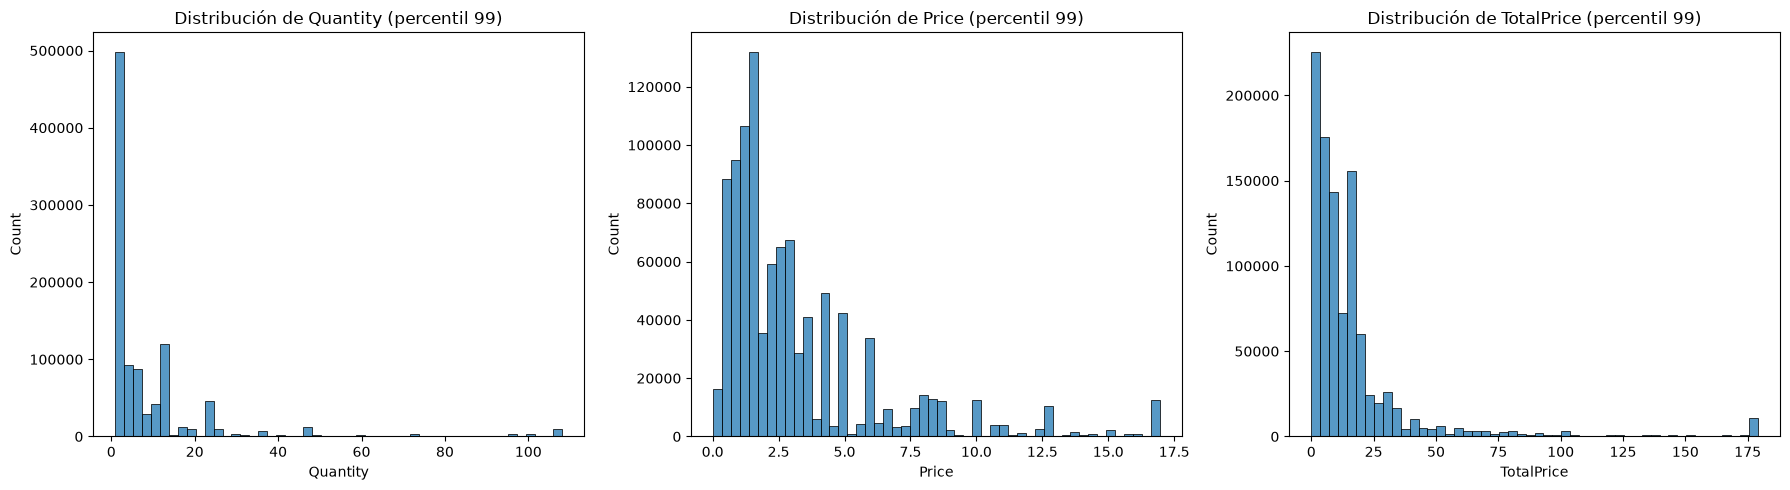

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Quantity'].clip(upper=df['Quantity'].quantile(0.99)), bins=50, ax=axes[0])
axes[0].set_title('Distribución de Quantity (percentil 99)')

sns.histplot(df['Price'].clip(upper=df['Price'].quantile(0.99)), bins=50, ax=axes[1])
axes[1].set_title('Distribución de Price (percentil 99)')

sns.histplot(df['TotalPrice'].clip(upper=df['TotalPrice'].quantile(0.99)), bins=50, ax=axes[2])
axes[2].set_title('Distribución de TotalPrice (percentil 99)')

plt.tight_layout()
plt.show()

### 6.8 Boxplots para identificación visual de outliers

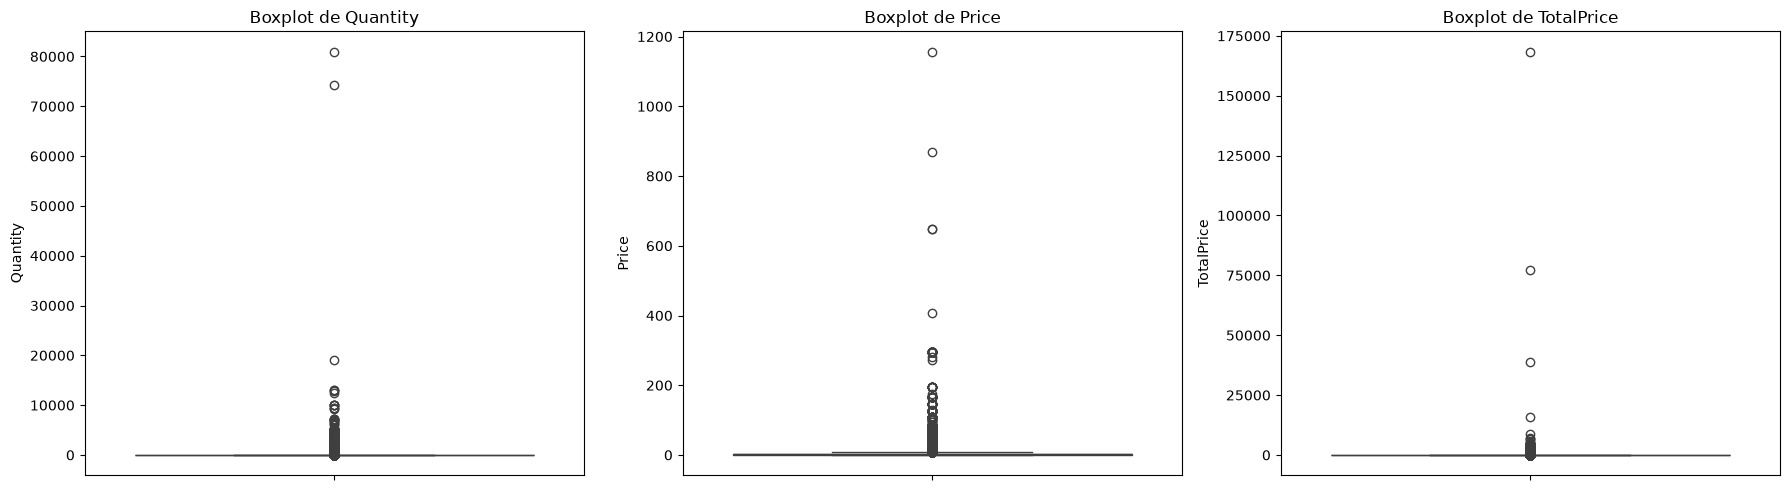

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(y=df['Quantity'], ax=axes[0])
axes[0].set_title('Boxplot de Quantity')

sns.boxplot(y=df['Price'], ax=axes[1])
axes[1].set_title('Boxplot de Price')

sns.boxplot(y=df['TotalPrice'], ax=axes[2])
axes[2].set_title('Boxplot de TotalPrice')

plt.tight_layout()
plt.show()

### 6.9 Conclusiones del análisis descriptivo general

- El dataset cubre **2 años** de transacciones (dic. 2009 – dic. 2011), con **40.077 facturas**, **4.917 productos**, **5.878 clientes** y **43 países**.
- Ingresos totales: **~20.47M** (tras eliminar registros administrativos).
- Las variables `Quantity`, `Price` y `TotalPrice` presentan una **fuerte asimetría a la derecha**: la mayoría de las líneas de venta son de bajo volumen e importe, con una cola de compras grandes correspondientes a clientes mayoristas.
- Dada esta asimetría, la **mediana** es más representativa que la **media** para describir la "compra típica".
- Se detectaron y eliminaron **4.699 registros administrativos** (ajustes manuales, comisiones, gastos de envío) que no representaban ventas reales de producto.
- Los outliers de `Quantity`/`Price` restantes corresponden a **compras mayoristas legítimas** y se han conservado en el dataset general.

## 7. Análisis descriptivo por categorías 


### 7.1 Ventas por país

In [34]:
ventas_pais = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

print("Top 10 países por ingresos:")
print(ventas_pais.head(10))

print("\n% que representa el Reino Unido del total:")
print(round(ventas_pais['United Kingdom'] / ventas_pais.sum() * 100, 2), "%") 

Top 10 países por ingresos:
Country
United Kingdom    16799849.90
Ireland             623414.16
Netherlands         549773.41
Germany             383289.00
France              311090.29
Australia           167800.01
Spain                97766.75
Switzerland          94024.59
Sweden               86319.14
Denmark              67422.69
Name: TotalPrice, dtype: float64

% que representa el Reino Unido del total:
85.53 %


### 7.2 Productos más vendidos

In [35]:
# Por unidades vendidas
top_productos_cantidad = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print("Top 10 productos por unidades vendidas:")
print(top_productos_cantidad)

# Por ingresos generados
top_productos_ingresos = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)
print("\nTop 10 productos por ingresos generados:")
print(top_productos_ingresos)

Top 10 productos por unidades vendidas:
Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     106139
WHITE HANGING HEART T-LIGHT HOLDER     94658
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          80082
MEDIUM CERAMIC TOP STORAGE JAR         78033
JUMBO BAG RED RETROSPOT                77699
BROCADE RING PURSE                     70369
PACK OF 60 PINK PAISLEY CAKE CASES     56061
60 TEATIME FAIRY CAKE CASES            54028
SMALL POPCORN HOLDER                   48561
Name: Quantity, dtype: int64

Top 10 productos por ingresos generados:
Description
REGENCY CAKESTAND 3 TIER               330590.32
WHITE HANGING HEART T-LIGHT HOLDER     260990.22
PAPER CRAFT , LITTLE BIRDIE            168469.60
PARTY BUNTING                          148318.28
JUMBO BAG RED RETROSPOT                148073.47
ASSORTED COLOUR BIRD ORNAMENT          129324.49
PAPER CHAIN KIT 50'S CHRISTMAS         117760.29
MEDIUM CERAMIC TOP STORAGE JAR          81700.92
CHILLI LIGHTS          

### 7.3 Evolución temporal de las ventas

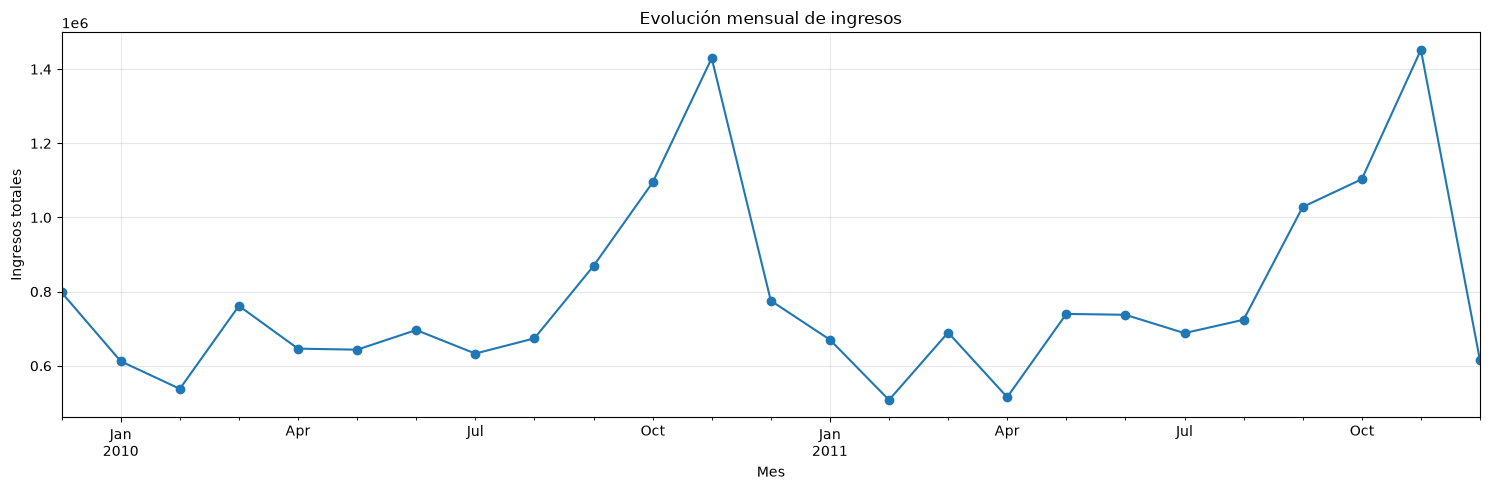

In [36]:
ventas_mensuales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalPrice'].sum()

plt.figure(figsize=(15, 5))
ventas_mensuales.plot(kind='line', marker='o')
plt.title('Evolución mensual de ingresos')
plt.xlabel('Mes')
plt.ylabel('Ingresos totales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 7.4 Verificación de meses incompletos

In [37]:
print("Primeras fechas del dataset:", df['InvoiceDate'].min())
print("Últimas fechas del dataset:", df['InvoiceDate'].max())

# Días con datos en diciembre de cada año
print("\nDías únicos con ventas en diciembre 2009:", df[(df['Year']==2009) & (df['Month']==12)]['Day'].nunique())
print("Días únicos con ventas en diciembre 2011:", df[(df['Year']==2011) & (df['Month']==12)]['Day'].nunique())

Primeras fechas del dataset: 2009-12-01 07:45:00
Últimas fechas del dataset: 2011-12-09 12:50:00

Días únicos con ventas en diciembre 2009: 21
Días únicos con ventas en diciembre 2011: 8


### 7.5 Ventas por día de la semana

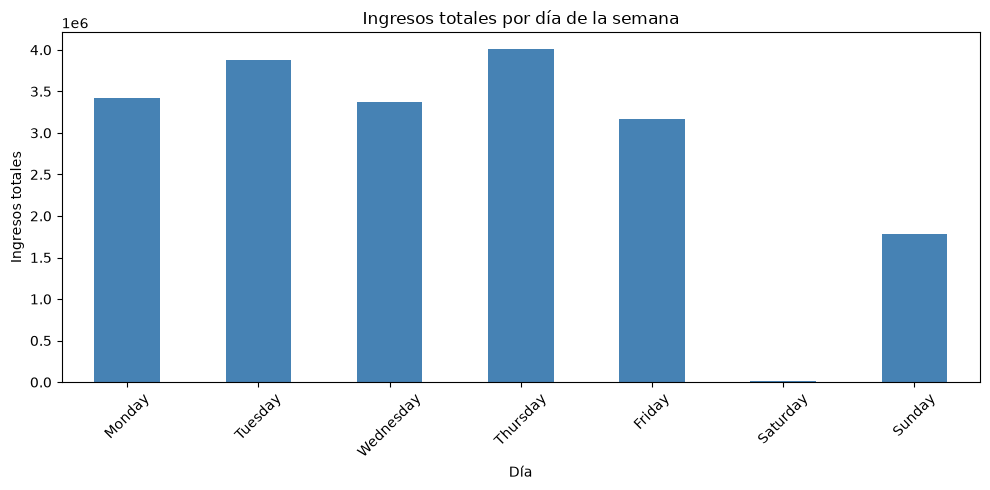

In [38]:
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ventas_dia = df.groupby('Weekday')['TotalPrice'].sum().reindex(orden_dias)

plt.figure(figsize=(10, 5))
ventas_dia.plot(kind='bar', color='steelblue')
plt.title('Ingresos totales por día de la semana')
plt.xlabel('Día')
plt.ylabel('Ingresos totales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.6 Conclusiones del análisis por categorías

- **Concentración geográfica**: el Reino Unido representa el **85.53%** de los ingresos totales — el negocio es predominantemente doméstico, con el resto de países (Irlanda, Países Bajos, Alemania, Francia) muy por detrás.
- **Productos**: el ranking de "más vendido" cambia según se mida en unidades o en ingresos — algunos productos se venden en gran volumen pero a bajo precio (ej. *Paper Craft, Little Birdie*), mientras otros aportan más ingresos con menor volumen (ej. *Regency Cakestand 3 Tier*, el producto que más ingresos genera).
- **Estacionalidad**: fuerte pico de ventas en **noviembre** (previo a Navidad) en ambos años, con tendencia de crecimiento interanual.
- **Diciembre incompleto**: el dataset solo cubre hasta el 9 de diciembre de 2011, lo que provoca una caída aparente (no real) en ese mes.
- **Patrón semanal**: los **sábados** tienen ventas prácticamente nulas, indicando que la operativa comercial no opera (o casi no opera) ese día. Jueves y martes son los días de mayor facturación.

## 8. Análisis estadístico

### 8.1 Matriz de correlación

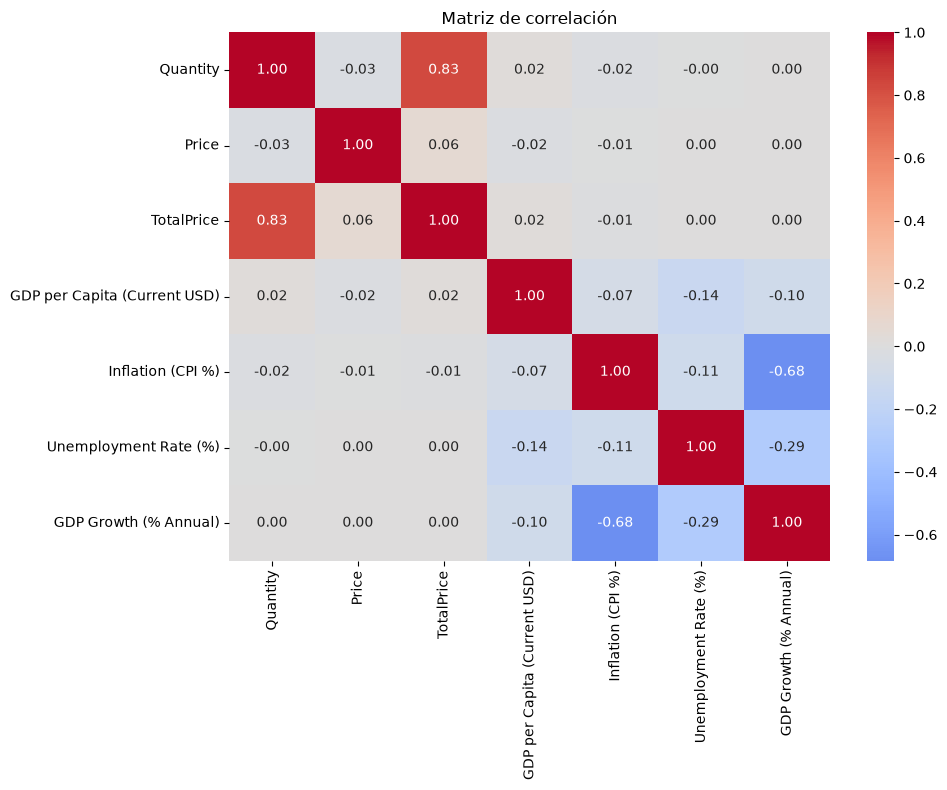

In [39]:
variables_numericas = ['Quantity', 'Price', 'TotalPrice', 'GDP per Capita (Current USD)', 
                         'Inflation (CPI %)', 'Unemployment Rate (%)', 'GDP Growth (% Annual)']

matriz_corr = df[variables_numericas].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación')
plt.tight_layout()
plt.show()

### 8.2 PIB per cápita vs. gasto medio por país

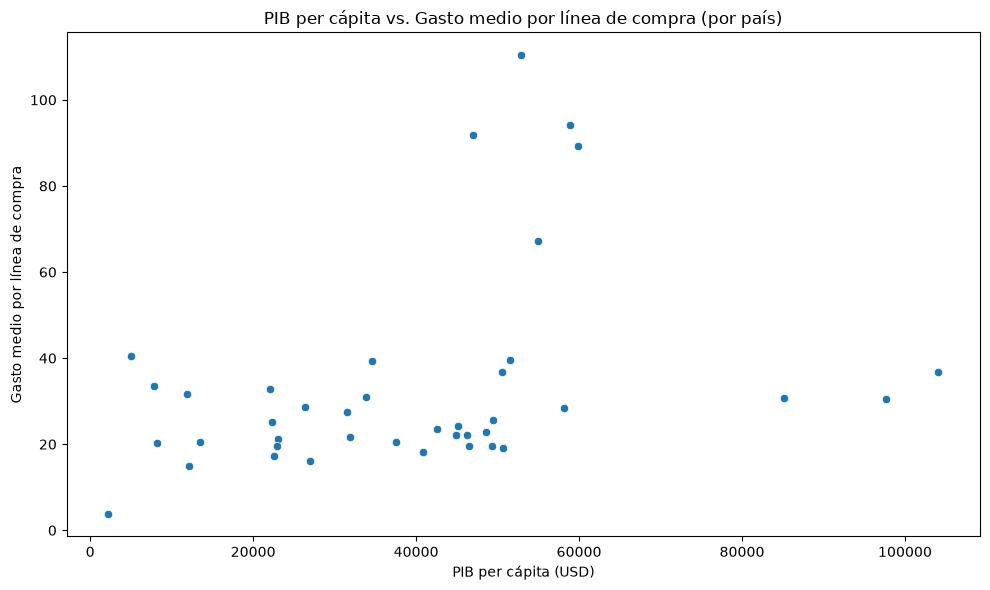

Correlación PIB per cápita vs Gasto medio: 0.324


In [40]:
gasto_por_pais = df.groupby('Country').agg(
    gasto_medio=('TotalPrice', 'mean'),
    pib_per_capita=('GDP per Capita (Current USD)', 'mean')
).dropna()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=gasto_por_pais, x='pib_per_capita', y='gasto_medio')
plt.title('PIB per cápita vs. Gasto medio por línea de compra (por país)')
plt.xlabel('PIB per cápita (USD)')
plt.ylabel('Gasto medio por línea de compra')
plt.tight_layout()
plt.show()

# Correlación numérica
correlacion = gasto_por_pais['pib_per_capita'].corr(gasto_por_pais['gasto_medio'])
print("Correlación PIB per cápita vs Gasto medio:", round(correlacion, 3))

### 8.3 Prueba de hipótesis: ¿Gasta distinto un cliente del Reino Unido que uno internacional?

In [43]:
from scipy import stats

gasto_uk = df[df['Country'] == 'United Kingdom']['TotalPrice']
gasto_resto = df[df['Country'] != 'United Kingdom']['TotalPrice']

t_stat, p_value = stats.ttest_ind(gasto_uk, gasto_resto, equal_var=False)

print("Gasto medio UK:", round(gasto_uk.mean(), 2))
print("Gasto medio resto de países:", round(gasto_resto.mean(), 2))
print("\nEstadístico t:", round(t_stat, 3))
print("p-valor:", p_value)

if p_value < 0.05:
    print("\n→ Diferencia estadísticamente significativa (p < 0.05)")
else:
    print("\n→ No hay diferencia estadísticamente significativa")

Gasto medio UK: 18.19
Gasto medio resto de países: 35.64

Estadístico t: -49.937
p-valor: 0.0

→ Diferencia estadísticamente significativa (p < 0.05)


### 8.4 Conclusiones del análisis estadístico

- **Correlación Quantity-TotalPrice**: 0.83 (fuerte, esperado matemáticamente).
- **Los indicadores macroeconómicos del país (PIB per cápita, inflación, desempleo) no muestran correlación relevante con el comportamiento de compra individual** (`Quantity`, `Price`, `TotalPrice`) — la decisión de compra no está condicionada por la salud económica del país del cliente.
- **Prueba t de Student**: existe una diferencia estadísticamente significativa (p ≈ 0.0) entre el gasto medio por línea de compra en el Reino Unido (18.19) y en el resto de países (35.64). A pesar de que UK genera el 85.5% de los ingresos totales por volumen de transacciones, el ticket medio internacional es prácticamente el doble, sugiriendo un perfil de cliente distinto (posiblemente más orientado a compra mayorista/reventa fuera de UK).

## 9. Visualizaciones exploratorias finales

En esta sección consolidamos los gráficos más relevantes del análisis, pensados para ilustrar los hallazgos principales en el informe final.

### 9.1 Ingresos por país (todos vs. excluyendo Reino Unido)

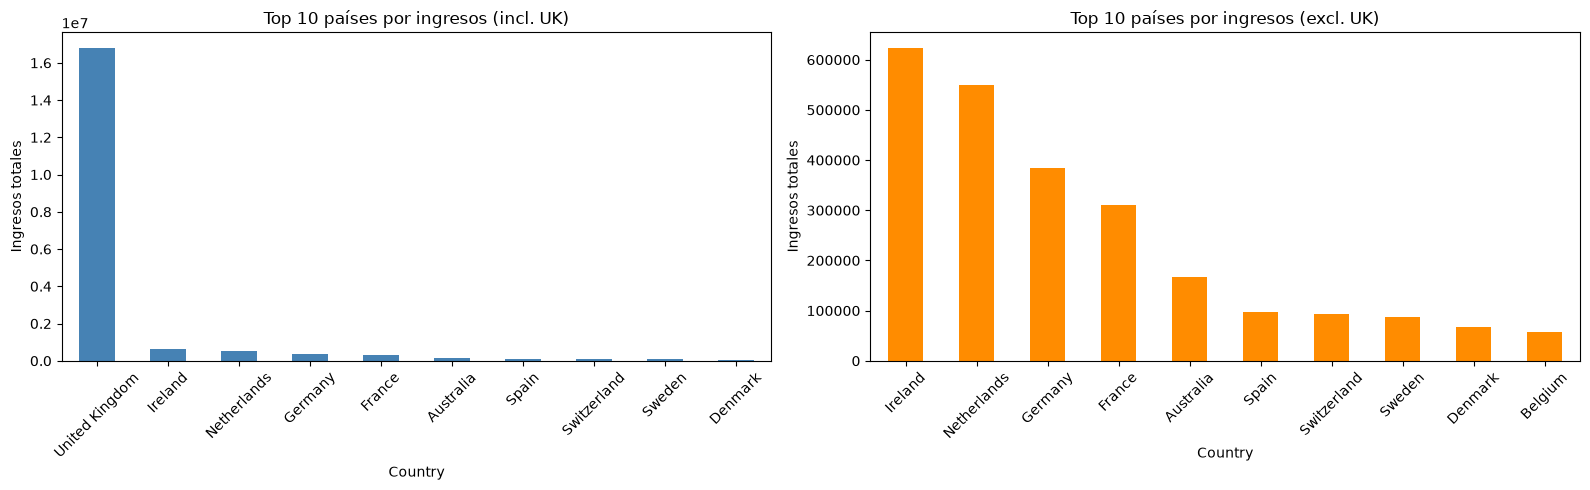

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Todos los países (top 10)
ventas_pais.head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 países por ingresos (incl. UK)')
axes[0].set_ylabel('Ingresos totales')
axes[0].tick_params(axis='x', rotation=45)

# Excluyendo UK
ventas_pais.drop('United Kingdom').head(10).plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 países por ingresos (excl. UK)')
axes[1].set_ylabel('Ingresos totales')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### 9.2 Top 10 productos por ingresos generados

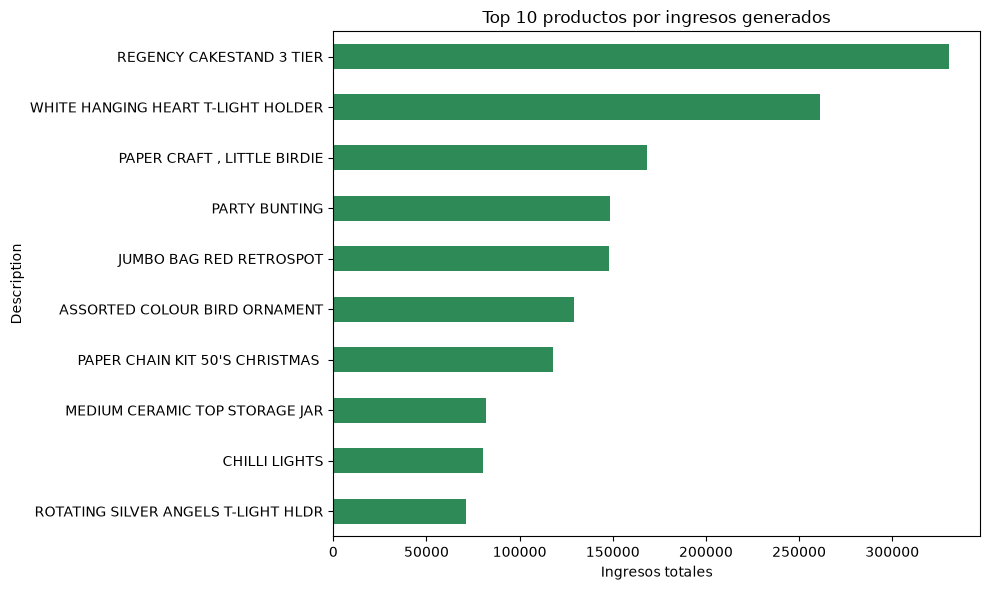

In [46]:
plt.figure(figsize=(10, 6))
top_productos_ingresos.sort_values().plot(kind='barh', color='seagreen')
plt.title('Top 10 productos por ingresos generados')
plt.xlabel('Ingresos totales')
plt.tight_layout()
plt.show()

### 9.3 Mapa de calor: estacionalidad de ventas (mes x año)

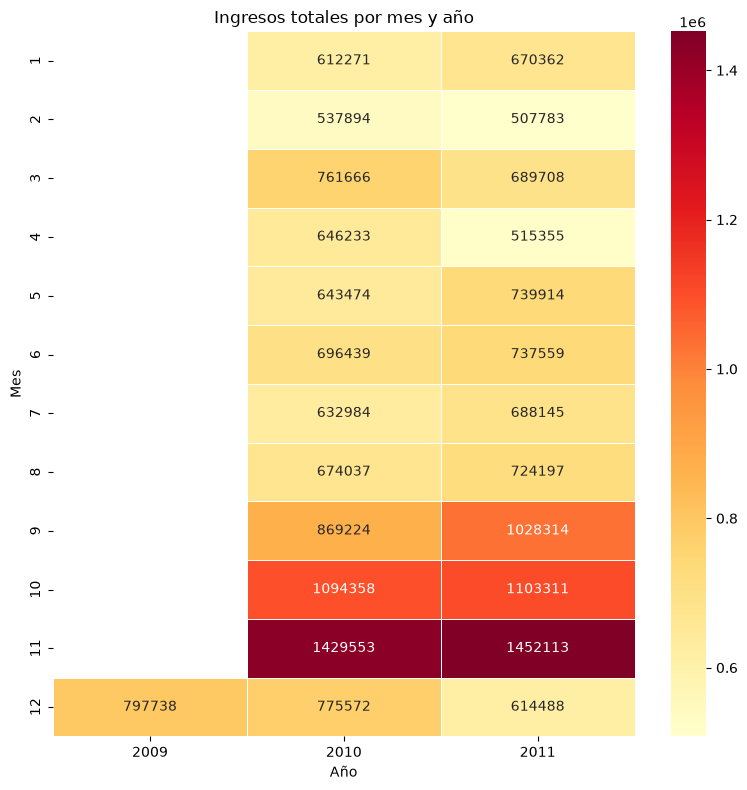

In [47]:
pivot_estacionalidad = df.pivot_table(
    index='Month', columns='Year', values='TotalPrice', aggfunc='sum'
)

plt.figure(figsize=(8, 8))
sns.heatmap(pivot_estacionalidad, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title('Ingresos totales por mes y año')
plt.ylabel('Mes')
plt.xlabel('Año')
plt.tight_layout()
plt.show()

### 9.4 Comparativa de gasto medio: UK vs. resto de países

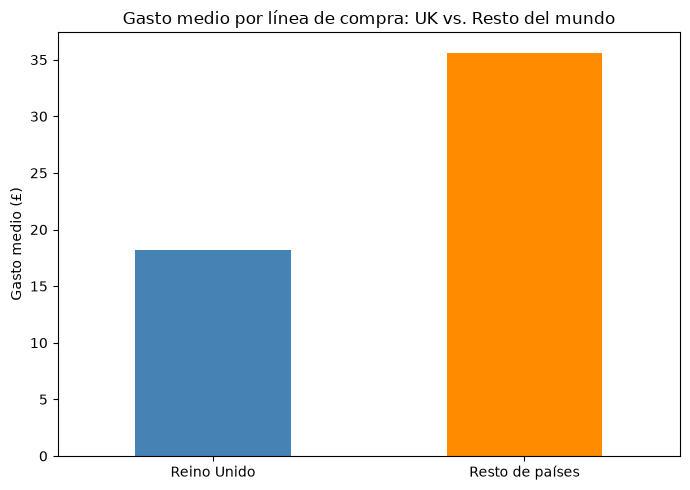

In [48]:
comparativa = pd.Series({
    'Reino Unido': gasto_uk.mean(),
    'Resto de países': gasto_resto.mean()
})

plt.figure(figsize=(7, 5))
comparativa.plot(kind='bar', color=['steelblue', 'darkorange'])
plt.title('Gasto medio por línea de compra: UK vs. Resto del mundo')
plt.ylabel('Gasto medio (£)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9.5 Cierre de las visualizaciones exploratorias

Las visualizaciones anteriores condensan los hallazgos principales del análisis:

1. Concentración geográfica de ventas en el Reino Unido, pero con mercados internacionales (Irlanda, Países Bajos, Alemania) con peso propio.
2. Jerarquía clara de productos por ingresos, liderada por *Regency Cakestand 3 Tier*.
3. Estacionalidad marcada con pico en noviembre, coherente con campañas de Navidad.
4. Paradoja del gasto medio: pese a menor volumen de ingresos, los clientes internacionales gastan de media casi el doble por línea de compra que los del Reino Unido.

---
## Fin del Notebook 2

Este notebook cubre las secciones 5 a 9: carga del dataset final, análisis descriptivo general y por categorías, análisis estadístico (correlaciones y prueba de hipótesis), y visualizaciones exploratorias clave.

**Siguientes pasos del proyecto:**
- Construcción del dashboard operativo en Power BI (a partir de `data/processed/retail_final.csv`)
- Redacción del informe explicativo del análisis
- Elaboración del README.md del repositorio